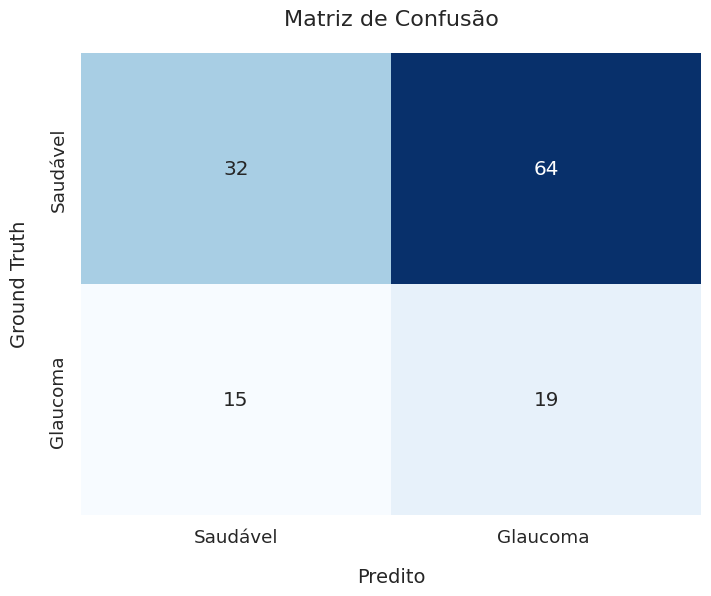


Relatório de Classificação (Check das métricas):
              precision    recall  f1-score   support

    Saudável       0.68      0.33      0.45        96
   Glaucoma        0.23      0.56      0.32        34

    accuracy                           0.39       130
   macro avg       0.45      0.45      0.39       130
weighted avg       0.56      0.39      0.42       130



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Configuração do Cenário (20% do ORIGA)
# Total Teste: 130 imagens
# Reais: 34 Glaucoma (1), 96 Saudáveis (0)

# Construindo os vetores de Ground Truth (Realidade)
# 15 FN + 19 TP = 34 Glaucoma
# 32 TN + 64 FP = 96 Saudáveis
y_true = np.array(
    [1] * 34 +  # Todos os casos reais de Glaucoma
    [0] * 96    # Todos os casos reais de Saudáveis
)

# Construindo as Predições do Modelo (Simulando o resultado ruim)
# O modelo acerta 19 Glaucomas, mas erra 15 (diz que é 0)
# O modelo acerta 32 Saudáveis, mas erra 64 (diz que é 1 - O grande problema!)
y_pred = np.array(
    # Para os 34 Glaucomas reais:
    [1] * 19 + [0] * 15 +
    # Para os 96 Saudáveis reais:
    [1] * 64 + [0] * 32
)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

# Rótulos para o plot
labels = ['Saudável', 'Glaucoma ']

# 3. Plotagem
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)

# Criando o Heatmap
# fmt='d' formata os números como inteiros
# cmap='Blues' deixa visualmente mais limpo
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, cbar=False)

plt.xlabel("Predito", fontsize=14, labelpad=15)
plt.ylabel("Ground Truth", fontsize=14, labelpad=15)
plt.title(f"Matriz de Confusão", fontsize=16, pad=20)

# Adicionando explicações visuais nas células
# (Posicionamento manual aproximado para fins didáticos no plot)

plt.show()

# 4. Imprimir Relatório para conferência
print("\nRelatório de Classificação (Check das métricas):")
print(classification_report(y_true, y_pred, target_names=labels))